# Trabalho 3 - MC920 - Processamento de imagem digital

## Nícolas Hecker Silva (186132)


# Apresentação
Nesse trabalho iremos utilizar técnicas de correção da rotação de uma imagem através do uso de algoritmos detectores de bordas (como o Canny) e posteriormente algoritmos para encontrar o ângulo de imagens, como o algoritmo baseado em projeção horizontal, ou um algoritmo baseado na transformada de Hough para retas. Esses algoritmos auxiliam no processo de encontrar uma entrada melhor para o algoritmo tesseract, que busca identificar o texto de uma imagem e apresentar a sequencia de caracteres contida nela.

Para atinigr tal objetivo, dividiremos em etapas: explorar o alinhamento por projeção horizontal, explorar o alinhamento por Hough e por fim realizar os testes com OCR.

Precisaremos também de um conjunto de bibliotecas e utilizaremos a função de apresentação de imagens criada em trabalhos anteriores. (Abaixo)

In [1]:
# carregar e mostrar imagem neg_4.png
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar(imagens: list, titulos=[], cmaps=[], eixos = False, minmax=None, num=[]):
    if type(imagens) == list:
        if type(imagens[0]) == list:
            fig, axs = plt.subplots(len(imagens), len(imagens[0]), figsize=(5*len(imagens[0]), 5*len(imagens)))
            for i in range(len(imagens)):
                for j in range(len(imagens[i])):
                    imagem = imagens[i][j]
                    if cmaps[i]:
                        axs[i][j].imshow(imagem, cmap=cmaps[i][j])
                    else:
                        axs[i][j].imshow(imagem)
                    if titulos[i]:
                        axs[i][j].set_title(titulos[i][j])
                    if not eixos:
                        axs[i][j].axis("off")
                    if len(num) > 0 and num[i]:
                        for x in range(imagem.shape[0]):
                            for y in range(imagem.shape[1]):
                                axs[i][j].text(y, x, str(round(imagem[x,y],2)), ha='center', va='center', color='r', fontsize=8)
        else:
            fig, axs = plt.subplots(1, len(imagens), figsize=(5*len(imagens),5*len(imagens)))
            if len(imagens) == 1:
                axs = [axs]
            for i, imagem in enumerate(imagens):
                if cmaps:
                    axs[i].imshow(imagem, cmap=cmaps[i])
                else:
                    axs[i].imshow(imagem)
                if titulos:
                    axs[i].set_title(titulos[i])
                if not eixos:
                    axs[i].axis("off")
                if len(num) > 0 and num[i]:
                    for x in range(imagem.shape[0]):
                        for y in range(imagem.shape[1]):
                            axs[i].text(y, x, str(round(imagem[x,y],2)), ha='center', va='center', color='r', fontsize=8)
        #diminui distancia lateral
        plt.subplots_adjust(wspace=0.1, hspace=0.1)
    else:
        if type(cmaps) != list:
            plt.imshow(imagens, cmap=cmaps)
        else:
            plt.imshow(imagens)
        if type(titulos) != list:
            plt.title(titulos)
        if not eixos:
            plt.axis("off")
        if type(num) != list:
            for x in range(imagens.shape[0]):
                for y in range(imagens.shape[1]):
                    plt.text(y, x, str(round(imagem[x,y],2)), ha='center', va='center', color='r', fontsize=8)
    plt.show()
    

# Alinhamento por projecao horizontal

Para realizar essa técnica é necessário primeiro carregar a imagem disponível e visualizá-la. Ela possui 3 canais de cores, e portanto seria necessário converter para tons de cinzas, mas a própria imagem sugeriu a utilização da função "cv2.CHAIN_APPROX_SIMPLE", então ela será utilizada.

Outro ponto a se prestar atenção antes de entrar no algoritmo, é a de que o fundo é branco, mas quando uma imagem é rotacionada, o fundo adicionado é preto, logo é necessário inverter os tons de cinza da imagem, para garantir que nenhuma forma extra irá surgir e atrapalhar a medição por conta do fundo branco. Assim, o texto será branco e deve ser analisado dessa forma invertida.

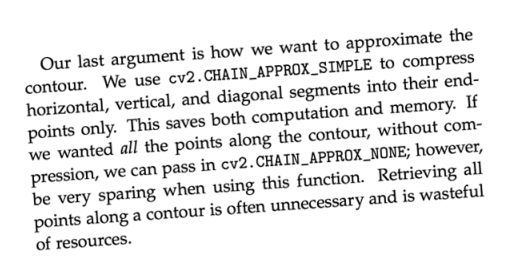

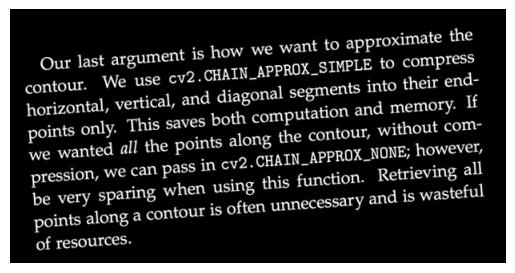

In [2]:

img = cv2.imread('neg_4.png', cv2.CHAIN_APPROX_SIMPLE)
mostrar(img, cmaps='gray')
imagem_neg = cv2.bitwise_not(img)
mostrar(imagem_neg, cmaps='gray')


## O algoritmo

O algoritmo da projeção horizontal se baseia no fato que escrevemos seguindo linhas retas horizontais, as vezes invisíveis, mas mantemos um espaço vazio entre elas e suas letras. Portanto, a projeção horizontal das letras na borda vertical lateral, garantirá o menor comprimento (não contínuo) possível, ou seja, uma grande parte dessa projeção irá se sobrepor.

Para realizar a medição através disso, medimos o número de linhas com pixels de letras (aqui, pixels com intensidade maior que 128) e rotacionamos a imagem em 1 grau. Ao final, verificamos qual grau garantiu o menor número de linhas com pixels. Esse grau será o grau que a imagem deve ser rotacionada para corrigir a orientação. Abaixo é mostrado uma versão ainda sem o código da rotação, mas com código de apresentação dos pixels no contador horizontal. Podemos verificar que nessa rotação, esse histograma ocupa um grande espaço vertical, mostrando que pode ser compactado de alguma forma ao rotacionar a imagem. (Há mais explicação do algoritmo abaixo)


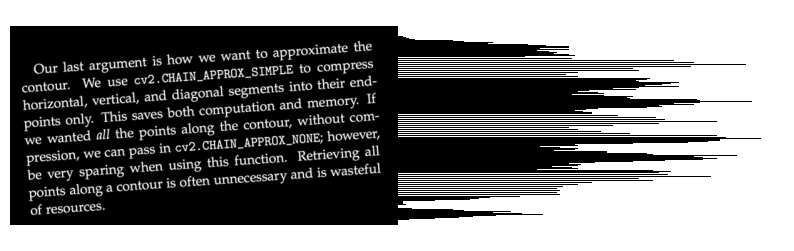

In [3]:
def rotaciona(imagem, angulo):
    return imagem.copy()

def encontrar_angulo_projecao_horizontal(imagem):
    angulo = 0
    angulo_teste = 0
    imagem_rotacionada = rotaciona(imagem, angulo_teste)
    linhas = []
    for linha in range(imagem_rotacionada.shape[0]):
        linhas.append(np.sum(imagem_rotacionada[linha] > 128))

    _, axs = plt.subplots(1, 2, figsize=(10,3))
    axs[0].imshow(imagem_rotacionada, cmap='gray')
    axs[0].axis("off")
    axs[1].barh(range(imagem_rotacionada.shape[0]), width=linhas[::], color='black')
    axs[1].invert_yaxis()
    axs[1].axis("off")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

encontrar_angulo_projecao_horizontal(imagem_neg)

    

O código então é completado e apresentado uma versão que printa os candidatos a ângulos sempre que o candidato anterior é descartado. Quando isso ocorre, o algoritmo recebe o ângulo novo e salva também o número de linhas com pixels. Para encontrar um novo candidato, ele procura um ângulo de -180 a 180 que possua menos linhas horizontais com pixels de caracteres. O processo é executado apenas uma vez para cada ângulo.

Abaixo podemos ver que o algoritmo considerou os ângulos -180 (inicial) com 273 linhas com pixels. depois considerou o -10 (um longo intervalo sem melhora), depois cada novo ângulo garante uma melhora, até o máximo de -4 graus, com 193 linhas com pixels, uma diferença de 80 linhas do caso original.

In [4]:
def rotaciona(imagem, angulo):
    centro = (imagem.shape[1]//2, imagem.shape[0]//2)
    matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    imagem_rotacionada = cv2.warpAffine(imagem, matriz_rotacao, (imagem.shape[1], imagem.shape[0]))
    return imagem_rotacionada

def encontrar_angulo_projecao_horizontal(imagem):
    angulo = (None, np.Inf)
    for angulo_teste in range(-180, 180):
        imagem_rotacionada = rotaciona(imagem, angulo_teste)
        linhas = []
        for linha in range(imagem_rotacionada.shape[0]):
            linhas.append(np.sum(imagem_rotacionada[linha] > 128))
        # conta a quantidade de linhas com pelo menos um pixel branco
        qtd_linhas_brancas = np.sum(np.array(linhas) > 0)
        if qtd_linhas_brancas < angulo[1]:
            angulo = (angulo_teste, qtd_linhas_brancas)
            print(angulo)
    return angulo[0]
    

print(encontrar_angulo_projecao_horizontal(imagem_neg))

(-180, 273)
(-10, 266)
(-9, 257)
(-8, 248)
(-7, 244)
(-6, 242)
(-5, 236)
(-4, 193)
-4


Por fim podemos funcionalizar o código e utilizar em diversas imagens para análise

In [5]:
def encontrar_angulo_projecao_horizontal(imagem):
    angulo = (None, np.Inf)
    for angulo_teste in range(-180, 180):
        imagem_rotacionada = rotaciona(imagem, angulo_teste)
        linhas = []
        for linha in range(imagem_rotacionada.shape[0]):
            linhas.append(np.sum(imagem_rotacionada[linha] > 128))
        # conta a quantidade de linhas com pelo menos um pixel branco
        qtd_linhas_brancas = np.sum(np.array(linhas) > 0)
        if qtd_linhas_brancas < angulo[1]:
            angulo = (angulo_teste, qtd_linhas_brancas)
    return angulo[0]

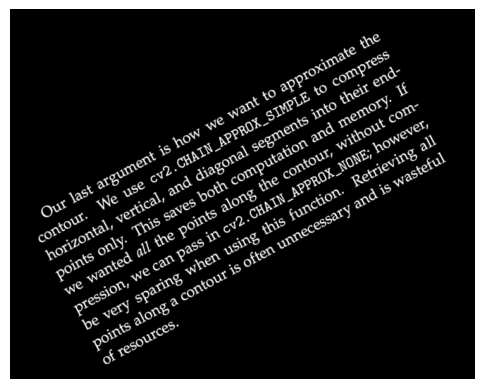

-28


In [6]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('neg_28.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))

Acima podemos verificar que o algoritmo predisse corretamente o ângulo -28 como indicado no nome da imagem "neg_28.png".

Na imagem abaixo porém, o resultado foi o negativo do esperado (ao invés de +24, o algoritmo respondeu -156). Isso acontece, pois essa técnica não faz diferença se a imagem está de ponta cabeça ou não, e como ele busca o ângulo com menor número de linhas horizontais com pixels começando de -180, o primeiro valor encontrado foi -156, que possui os mesmos espaços vazios que a imagem rotacionada em +24.

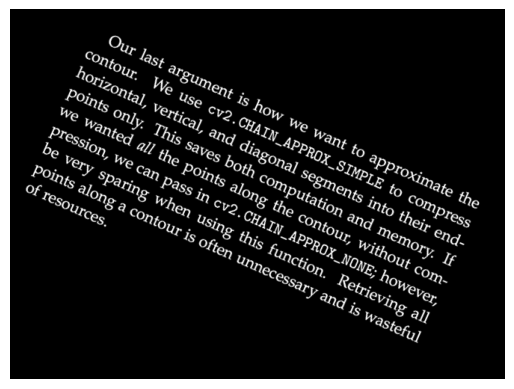

-156


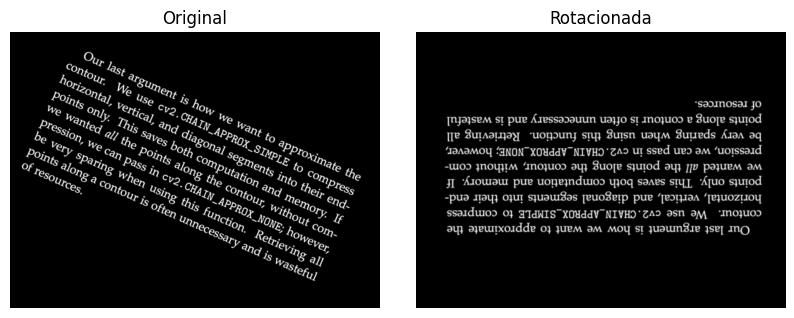

In [7]:
imagem_24 = cv2.bitwise_not(cv2.imread('pos_24.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_24, cmaps='gray')

angulo = encontrar_angulo_projecao_horizontal(imagem_24)
print(angulo)
imagem_rotacionada = rotaciona(imagem_24, angulo)
mostrar([imagem_24, imagem_rotacionada], ['Original', 'Rotacionada'], ['gray', 'gray'])

Dessa forma podemos verificar que nem todos os casos sao possiveis de resolver, exigindo analise manual, mas podemos supor que as amostras estão levemente rotacionadas, ou seja, o angulo de correção é aquele com menor módulo, para isso fazemos modificacao no algoritmo: Variamos o ângulo de 0 a 180 e testamos o seu valor negativo depois seu valor positivo, por exemplo, o algoritmo vai testar o valor 5. Ao invés de simplesmente rotacionar a imagem em 5, ele rotaciona em -5 e depois 5, assim ele cerca os dois módulos 5 primeiro antes de ir para -175, que seria a rotação equivalente. Se a imagem estiver muito rotacionada, o resultado ainda sairá de ponta cabeça, mas esse procedimento resolve para todas as imagens fornecidas.

In [8]:
def rotaciona(imagem, angulo):
    centro = (imagem.shape[1]//2, imagem.shape[0]//2)
    matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    imagem_rotacionada = cv2.warpAffine(imagem, matriz_rotacao, (imagem.shape[1], imagem.shape[0]))
    return imagem_rotacionada

def encontrar_angulo_projecao_horizontal(imagem):
    angulo = (None, np.Inf)
    for angulo_teste in range(0, 180):
        for i in range(-1, 2, 2):
            imagem_rotacionada = rotaciona(imagem, angulo_teste*i)
            linhas = []
            for linha in range(imagem_rotacionada.shape[0]):
                linhas.append(np.sum(imagem_rotacionada[linha] > 128))
            # conta a quantidade de linhas com pelo menos um pixel branco
            qtd_linhas_brancas = np.sum(np.array(linhas) > 0)
            if qtd_linhas_brancas < angulo[1]:
                angulo = (angulo_teste*i, qtd_linhas_brancas)
    return angulo[0]
    

print(encontrar_angulo_projecao_horizontal(imagem_24))

24


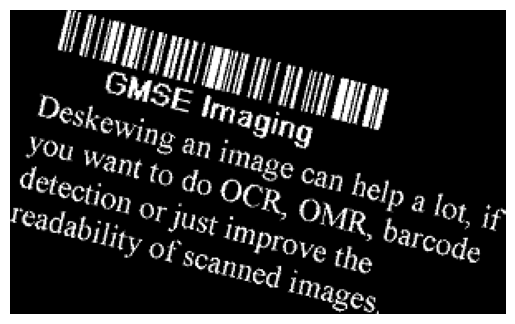

14


In [9]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('sample1.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))

O algoritmo é testado em uma amostra sem rótulo de rotação e apresenta a resposta de 14 graus, o que parece fazer sentido visualmente, por ser uma rotação leve.

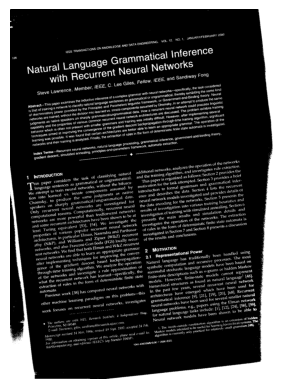

89


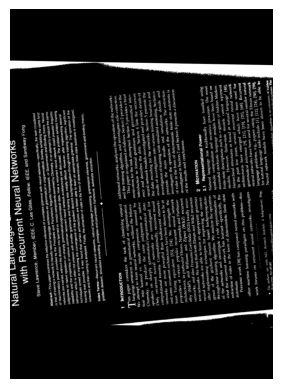

In [10]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('sample2.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))
mostrar(rotaciona(imagem_neg_28, encontrar_angulo_projecao_horizontal(imagem_neg_28)), cmaps='gray')

Em contrapartida, o algoritmo foi aplicado a uma folha digitalizada e apresentou uma rotação muito maior que o esperado, isso porque ela é muito menos uniforme e não há muitas linhas vazias entre os caracteres. dessa forma o código não conseguiu resolver o problema de forma eficiente, sendo necessário algum algoritmo mais detalhado.

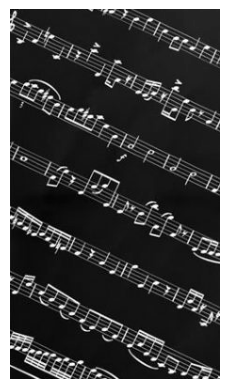

28


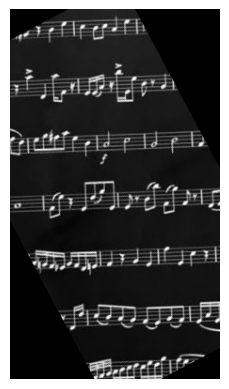

In [11]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('partitura.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))
mostrar(rotaciona(imagem_neg_28, encontrar_angulo_projecao_horizontal(imagem_neg_28)), cmaps='gray')

# Parte 2 -  Transformada de Hough

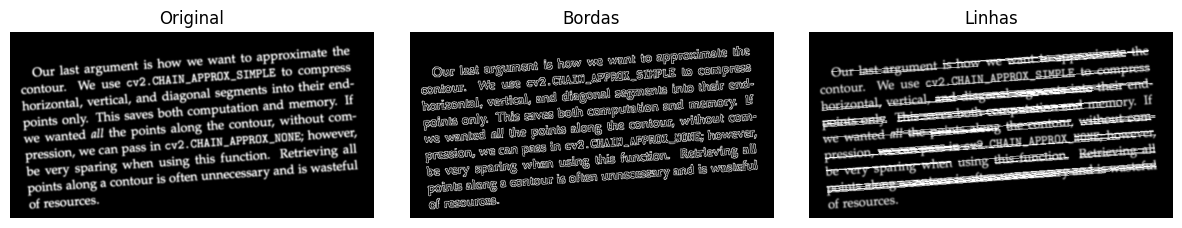

-3.9570705509478667


In [12]:
# realiza a transformada de hough para encontrar as linhas da pauta
def encontrar_linhas(imagem, debug=False):
    imagem = cv2.GaussianBlur(imagem, (5, 5), 0)
    bordas = cv2.Canny(imagem, 50, 150)
    linhas = cv2.HoughLinesP(bordas, 1, np.pi/180, 100, minLineLength=100, maxLineGap=10) #  x1, y1, x2, y2
    if debug:
        imagem_linhas = imagem.copy()
        for linha in linhas:
            x1, y1, x2, y2 = linha[0]
            cv2.line(imagem_linhas, (x1, y1), (x2, y2), (255, 0, 0), 1)
        mostrar([imagem, bordas, imagem_linhas], ['Original', 'Bordas', 'Linhas'], ['gray', 'gray', 'gray'])

    return np.squeeze(linhas)

def angulo_medio(linhas):
    angulos = []
    for linha in linhas:
        x1, y1, x2, y2 = linha
        if x1 == x2: # vertical
            if y2 > y1: # para baixo
                angulo = 90
            elif y2 < y1:   # para cima
                angulo = -90
            else:
                angulo = 0  # ponto
        else:
            angulo = np.arctan2(y2-y1, x2-x1) * 180 / np.pi
        angulos.append(angulo)
    return np.mean(angulos)

imagem_neg_28 = cv2.bitwise_not(cv2.imread('neg_4.png', cv2.CHAIN_APPROX_SIMPLE))
linhas = encontrar_linhas(imagem_neg_28, True)
print(angulo_medio(linhas))



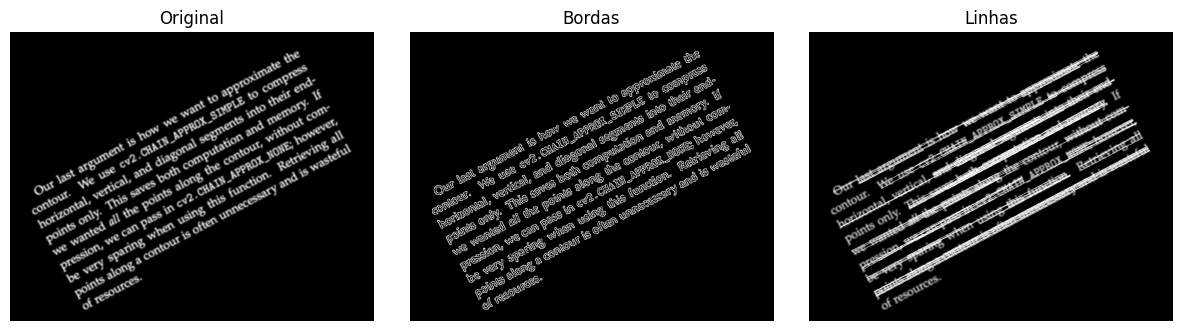

-28.00211525783994


In [13]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('neg_28.png', cv2.CHAIN_APPROX_SIMPLE))
linhas = encontrar_linhas(imagem_neg_28, True)
print(angulo_medio(linhas))

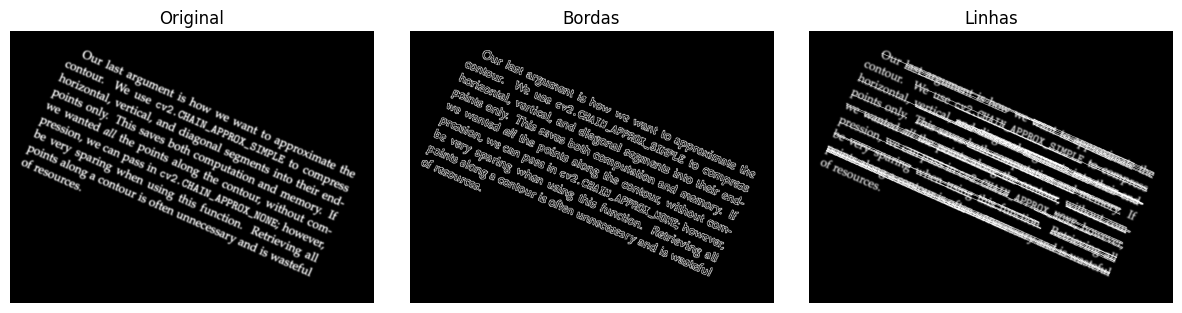

23.886026789037203


In [14]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('pos_24.png', cv2.CHAIN_APPROX_SIMPLE))
linhas = encontrar_linhas(imagem_neg_28, True)
print(angulo_medio(linhas))

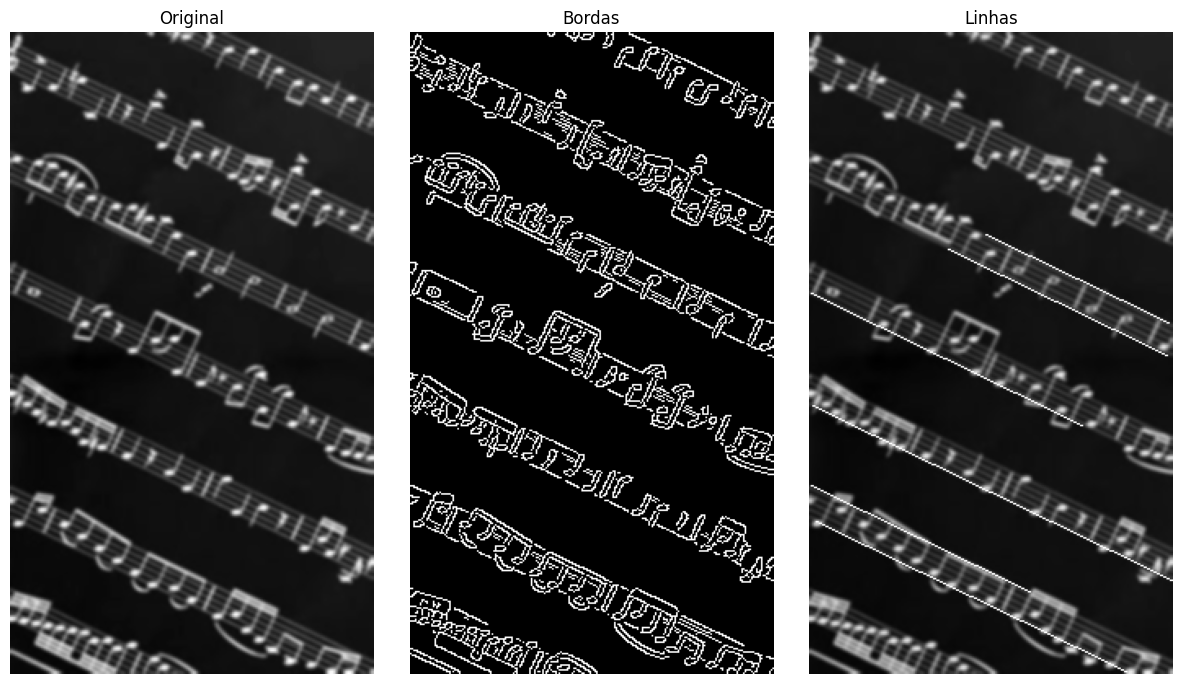

25.8796508584814


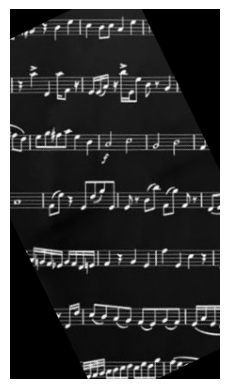

In [15]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('partitura.png', cv2.CHAIN_APPROX_SIMPLE))
linhas = encontrar_linhas(imagem_neg_28, True)
print(angulo_medio(linhas))
mostrar(rotaciona(imagem_neg_28, angulo_medio(linhas)), cmaps='gray')

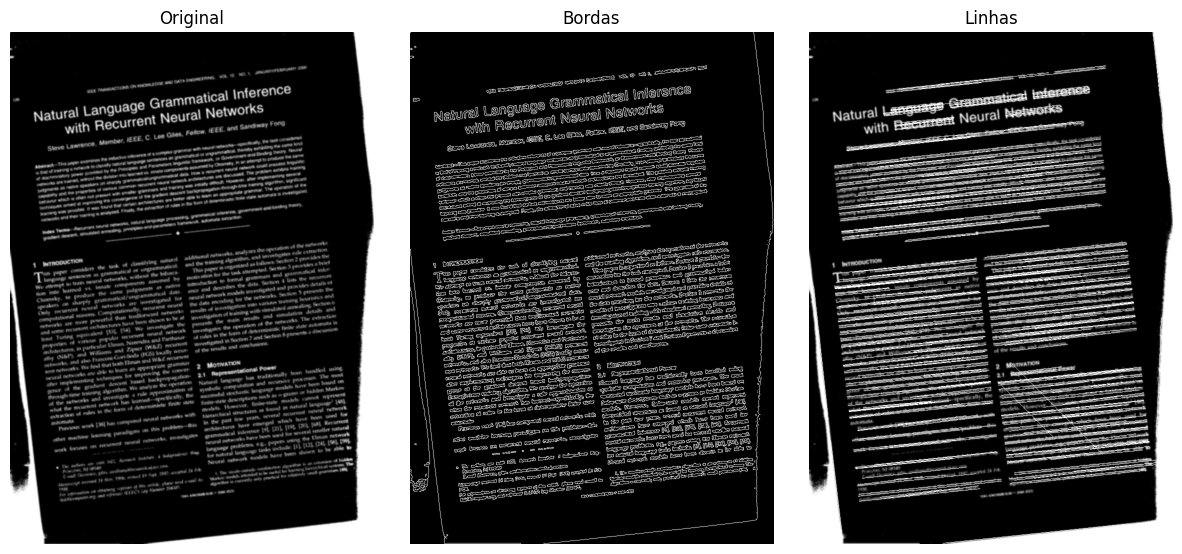

-5.156053656825824


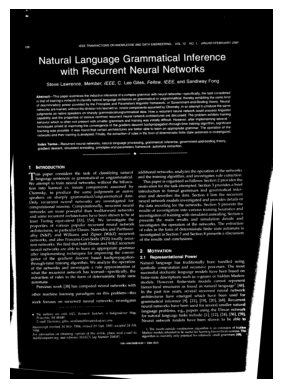

In [16]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('sample2.png', cv2.CHAIN_APPROX_SIMPLE))
linhas = encontrar_linhas(imagem_neg_28, True)
print(angulo_medio(linhas))
mostrar(rotaciona(imagem_neg_28, angulo_medio(linhas)), cmaps='gray')

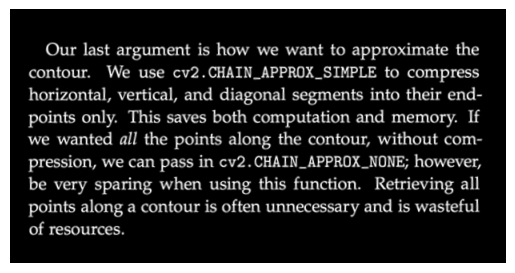

Texto da imagem original:
ene eater is how we want to approximate the
contour. We use Reem ae romeo ood
Pateret zeae eras eT RU Creo Pers CtLe Pats ag
points Pye ame Petmccns atc tas and memory. If
Beene BL ia rot PVTeyat aa Per ota e Ua ca
et we can pass Tames Revie \22 el Bennie
Coo me atta eee etna Pitter nmee cnn) EVN
PaO esi Peta kota Renee sae wasteful
Oe oe ae

Texto da imagem corrigida:
Our last argument is how we want to approximate the
contour. We use cv2.CHAIN_APPROX_SIMPLE to compress
horizontal, vertical, and diagonal segments into their end-
pelea Ren am CRM elcmaori ricco selale mee s as tg
we wanted all the points along the contour, without com-
pression, we can pass in cv2.CHAIN_APPROX_NONE; however,
LTC oa AR) tem POMS eam alc it reCas (oan oleae rarer tly
Oe ue Renee Rom seca ace ORCC ol
Cm cet eccs



In [19]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('neg_4.png', cv2.CHAIN_APPROX_SIMPLE))
linhas = encontrar_linhas(imagem_neg_28)
imagem_final = rotaciona(imagem_neg_28, angulo_medio(linhas))
mostrar(imagem_final, cmaps='gray')

#realiza ocr e encontra o texto da imagem

import pytesseract # pip install pytesseract

texto_rotacionado = pytesseract.image_to_string(imagem_neg_28, lang='eng')
texto_corrigido = pytesseract.image_to_string(imagem_final, lang='eng')
print("Texto da imagem original:")
print(texto_rotacionado)
print("Texto da imagem corrigida:")
print(texto_corrigido)
